# PTI-Clima Notebooks  <img src="https://www.r-project.org/logo/Rlogo.png" alt="Description" width="60" height="40">

***

> Este cuaderno o notebook muestra las operaciones básicas para calcular el Índice de Precipitación-Evapotranspiración Estandarizado (Standardised Precipitation-Evapotranspiration Index; SPEI) utilizando los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)

## Guía para el cálculo del SPEI

**M.ª I. de la Osa Rocha** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

**¡Bienvenidos al cuaderno "Guía para el cálculo del SPEI" de la Plataforma Virtual de Cálculo de la PTI-Clima!**  
Esta guía está diseñada para ayudarte a sacar el máximo provecho de los numerosos recursos disponibles en el [**Almacén de Datos de la PTI-Clima**](https://pti.climate.ifca.es/data). A través de esta plataforma, podrás realizar investigaciones y **análisis climáticos de relevancia**, ya que ofrece **acceso transparente a una amplia gama de materiales y datos** subyacentes a los **servicios climáticos desarrollados en la PTI-Clima**, fomentando su **reutilización** y posibilitando la **reproducibilidad** de los productos generados.

Concretamente, en este cuaderno/notebook calcularemos el Índice de Precipitación-Evapotranspiración Estandarizado a escala de 3 meses (SPEI-3). Para ello utilizaremos la librería de ***climate4R*** *drought4R*, que permite calcular el SPEI a partir de datos de precipitación y evapotranspiración (ETo).

Todo el flujo de trabajo se realiza con ***climate4R***, un framework de librerías en R para la carga, el postprocesado y el análisis de datos climáticos.

<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

Antes de empezar, o en cualquier momento durante el cuaderno, podemos personalizar el área de visualización de gráficos de la siguiente manera:

In [1]:
library(repr)
# Change plot size 
options(repr.plot.width=12, repr.plot.height=5)

### Contenido de este cuaderno:
*  [1. Características del SPEI](#1-bullet)
*  [2. Carga de librerías](#2-bullet)
*  [3. Carga de datos](#3-bullet)
*  [4. Cálculo del índice y visualización](#4-bullet)
   *  [4.1 Cálculo de la ETo](#4.1-bullet)
   *  [4.2 Cálculo del SPEI-3](#4.2-bullet)
   *  [4.3 Visualización](#4.3-bullet)

## 1. Características del SPEI <a class="anchor" id="1-bullet"></a>

El **SPEI** (Standardised Precipitation-Evapotranspiration Index) es un índice de sequía multivariable que combina la **precipitación** y la **evapotranspiración (ETo)** para cuantificar el déficit o superávit hídrico en una región.

Para el cálculo del SPEI-3 necesitamos:

+ **Precipitación diaria (mm)**: acumulada mensualmente para obtener precipitación mensual.
+ **Temperatura mínima diaria (ºC)** y **temperatura máxima diaria (ºC)**: promediadas mensualmente, necesarias para estimar la ETo mediante el método de **Hargreaves**, que también utiliza la precipitación mensual.

La ETo se calcula mediante la función `petGrid` de la librería `drought4R`, y el SPEI se obtiene a continuación con `speiGrid`, también de `drought4R`.

## 2. Carga de librerías <a class="anchor" id="2-bullet"></a>

Para las operaciones que se llevan a cabo en este notebook necesitaremos las siguientes librerías de ***climate4R***: `loadeR` para la carga de datos, `transformeR` para calcular agregaciones temporales y extraer subconjuntos de información, `visualizeR` para la representación gráfica de los resultados y `drought4R` para el cálculo de la ETo y el SPEI.

In [2]:
library(loadeR)
library(transformeR)
library(visualizeR)
library(drought4R)
library(magrittr)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

drought4R version 0.3.1 (2023-06-22) is loaded


Get the latest stable version (0.3.2) using <devtools::install_github('SantanderMetGroup/drought4R')>



## 3. Carga de datos <a class="anchor" id="3-bullet"></a>

El inventario `data_inventory.csv` cataloga la lista de archivos del Almacén de datos de la PTI-Clima. Consulta `primeros_pasos_R.ipynb` para una explicación detallada.

Basta con leer este archivo mediante `read.csv` para obtener el `data.frame` que contiene esta información.

In [3]:
df <- read.csv("../../data_inventory.csv")

A continuación mostramos el cabecero del inventario.

In [4]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-ROCIO-IBEB-regular_Iberia_day,observations,opendap,AEMET-ROCIO-IBEB-regular,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-ROCIO-IBEB_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-regular.dic
2,AEMET-ROCIO-CAN-regular_Canarias_day,observations,opendap,AEMET-ROCIO-CAN-regular,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-CAN/Canarias/day/AEMET-ROCIO-CAN_Canarias_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-regular.dic
3,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
5,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic


Para encontrar fácilmente el dataset que nos interesa, usaremos la función `subset`. Especificando `source == "PTI-grid"` obtenemos la lista de dos datasets, uno para la Península Ibérica (*Iberia*) y otro para las Islas Canarias (*Canarias*).

In [5]:
subset(df, source == "PTI-grid")

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
13,PTI-grid_Canarias_day,observations,opendap,PTI-grid,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid/Canarias/day/PTI-grid_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic
14,PTI-grid_Iberia_day,observations,opendap,PTI-grid,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid/Iberia/day/PTI-grid_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


El inventario nos indica cuál es el `endpoint` de cada dataset. Es decir, el enlace que necesitamos utilizar para la carga de datos.

Primero concretamos el dataset que queremos analizar y extraemos el elemento *endpoint*. Seleccionaremos la Península Ibérica.

In [6]:
dataset  <- subset(df, dataset == "PTI-grid_Iberia_day")

In [7]:
endpoint <- dataset$endpoint

Antes de cargar los datos, conviene revisar el dataset con `dataInventory`. Esta función devuelve un resumen útil del conjunto de datos, para entender qué información contiene y cómo está descrita (variables, unidades y cobertura temporal, entre otros aspectos).

In [8]:
di <- dataInventory(endpoint)

[2026-06-05 09:06:00.807478] Doing inventory ...

[2026-06-05 09:06:00.848838] Opening dataset...

[2026-06-05 09:06:01.851856] The dataset was successfuly opened

[2026-06-05 09:06:02.006064] Retrieving info for 'tasmin' (6 vars remaining)

[2026-06-05 09:06:02.104984] Retrieving info for 'tasmax' (5 vars remaining)

[2026-06-05 09:06:02.185481] Retrieving info for 'ssrd' (4 vars remaining)

[2026-06-05 09:06:02.251303] Retrieving info for 'wss' (3 vars remaining)

[2026-06-05 09:06:02.327129] Retrieving info for 'pr' (2 vars remaining)

[2026-06-05 09:06:02.392667] Retrieving info for 'hurs' (1 vars remaining)

[2026-06-05 09:06:02.465725] Retrieving info for 'tdps' (0 vars remaining)

[2026-06-05 09:06:02.529529] Done.



In [9]:
str(di)

List of 7
 $ tasmin:List of 7
  ..$ Description: chr "Minimum daily temperature"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 23799 342 545
  ..$ Units      : chr "ºC"
  ..$ DataSizeMb : num 17744
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time     :List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1970-01-01 00:00:00"
  .. .. ..$ Date_range: chr "1961-01-01T01:00:00Z - 2026-02-27T01:00:00Z"
  .. ..$ latitude :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:342] 35.3 35.3 35.3 35.4 35.4 ...
  .. .. ..$ Shape      : int 342
  .. .. ..$ Coordinates: chr "latitude"
  .. ..$ longitude:List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:545] -9.29 -9.26 -9.24 -9.21 -9.19 ...
  .. .. ..$ Shape      : int 545
  .. .. ..$ Coordinates: chr "longi

Este resumen facilita definir la petición de carga de datos. Necesitamos tres variables: `pr`, `tasmin` y `tasmax`. Las variables de temperatura de `PTI-grid` ya están en grados centígrados (ºC) y la precipitación en mm, por lo que no es necesario aplicar ninguna transformación de unidades.

Para acotar el dominio espacial, utilizaremos `lonLim` y `latLim` para cargar únicamente el **sureste peninsular**. Cargaremos el periodo 1961-2020 con todos los meses del año (`season = 1:12`), ya que `speiGrid` requiere la serie mensual completa para calcular correctamente la acumulación a 3 meses. La agregación mensual se aplica directamente en la carga. 

*NOTA: La operación de carga puede tardar unos minutos cuando se trata de conjuntos de datos de alta resolución*.

In [10]:
pr <- loadGridData(dataset = endpoint,
                   var     = "pr",
                   season  = 1:12,
                   years   = 1961:2020,
                   lonLim  = c(-3.5, 1.5),
                   latLim  = c(36.5, 41.5),
                   aggr.m  = "sum")

[2026-06-05 09:06:09.359666] Opening dataset...

[2026-06-05 09:06:09.516709] The dataset was successfuly opened

[2026-06-05 09:06:09.522964] Defining geo-location parameters

[2026-06-05 09:06:09.594679] Defining time selection parameters

NOTE: Daily data will be monthly aggregated

[2026-06-05 09:06:09.941948] Retrieving data subset ...

[2026-06-05 09:14:22.004681] Done



In [11]:
tasmin <- loadGridData(dataset = endpoint,
                       var     = "tasmin",
                       season  = 1:12,
                       years   = 1961:2020,
                       lonLim  = c(-3.5, 1.5),
                       latLim  = c(36.5, 41.5),
                       aggr.m  = "mean")

[2026-06-05 09:14:58.142483] Opening dataset...

[2026-06-05 09:14:58.256877] The dataset was successfuly opened

[2026-06-05 09:14:58.261404] Defining geo-location parameters

[2026-06-05 09:14:58.316354] Defining time selection parameters

NOTE: Daily data will be monthly aggregated

[2026-06-05 09:14:58.577532] Retrieving data subset ...

[2026-06-05 09:25:43.784891] Done



In [12]:
tasmax <- loadGridData(dataset = endpoint,
                       var     = "tasmax",
                       season  = 1:12,
                       years   = 1961:2020,
                       lonLim  = c(-3.5, 1.5),
                       latLim  = c(36.5, 41.5),
                       aggr.m  = "mean")

[2026-06-05 09:27:51.434227] Opening dataset...

[2026-06-05 09:27:51.540481] The dataset was successfuly opened

[2026-06-05 09:27:51.545367] Defining geo-location parameters

[2026-06-05 09:27:51.604184] Defining time selection parameters

NOTE: Daily data will be monthly aggregated

[2026-06-05 09:27:51.878612] Retrieving data subset ...

[2026-06-05 09:38:34.484775] Done



## 4. Cálculo del índice y visualización <a class="anchor" id="4-bullet"></a>

### 4.1 Cálculo de la ETo <a class="anchor" id="4.1-bullet"></a>

El primer paso es calcular la **evapotranspiración (ETo)** mediante el método de Hargreaves, que requiere temperatura mínima, máxima y precipitación. Para ello usamos la función `petGrid` de `drought4R`.

In [13]:
pet <- petGrid(tasmin = tasmin, tasmax = tasmax, pr = pr, method = "hargreaves")

[2026-06-05 09:38:52.745553] Computing PET-hargreaves ...

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

[2026-06-05 09:39:20.962034] Done



### 4.2 Cálculo del SPEI-3 <a class="anchor" id="4.2-bullet"></a>

Con la precipitación mensual y la ETo ya calculada, podemos obtener el SPEI-3 con la función `speiGrid` de `drought4R`. El parámetro `scale = 3` indica que el balance hídrico se acumula a 3 meses. Los parámetros `ref.start` y `ref.end` definen el periodo de referencia climatológico (1981-2016), que es el periodo que se usa como "normal": un valor de SPEI-3 muy negativo en cualquier año indica que ese trimestre fue más seco de lo habitual en 1981-2016, y uno muy positivo indica que fue más húmedo.

In [14]:
spei3 <- speiGrid(pr.grid   = pr,
                  et0.grid  = pet,
                  scale     = 3,
                  ref.start = c(1981, 1),
                  ref.end   = c(2016, 12),
                  na.rm     = TRUE)
spei3$Data[which(is.infinite(spei3$Data))] <- NA
spei3 <- redim(spei3, drop = TRUE)

[2026-06-05 09:40:01.731593] Computing SPEI-3 ...

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

[2026-06-05 09:51:47.743728] Done



### 4.3 Visualización <a class="anchor" id="4.3-bullet"></a>

Mediante `temporalPlot` visualizamos la **serie temporal** del SPEI-3 para el periodo 1961-2020. Los valores positivos indican condiciones más húmedas de lo normal y los negativos indican sequía.

pad applied on the interval: month



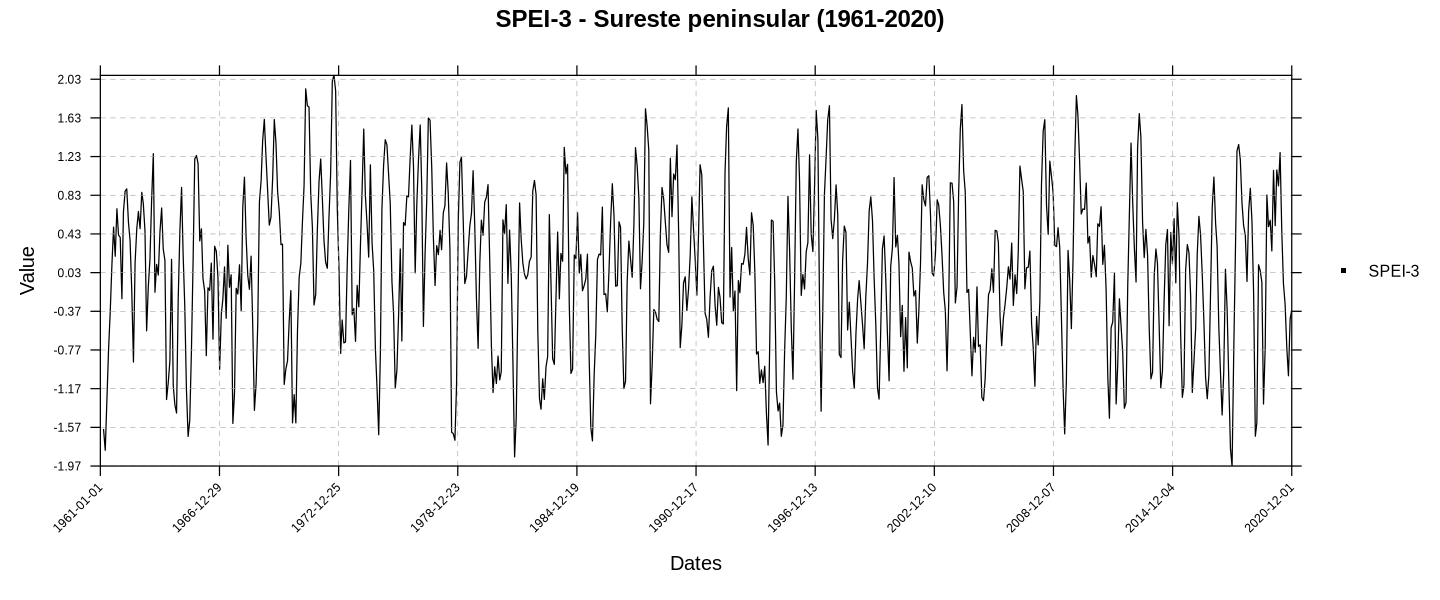

In [15]:
temporalPlot("SPEI-3" = spei3,
             xyplot.custom = list(main = "SPEI-3 - Sureste peninsular (1961-2020)"))

Para la visualización espacial, calculamos la **climatología** del SPEI-3 (Junio-Agosto) con `climatology` y la representamos con `spatialPlot` para los dos periodos consecutivos (1961-1990 y 1991-2020).

In [16]:
spei3.jja <- subsetGrid(spei3, season = 6:8)
spei3.p1 <- subsetGrid(spei3.jja, years = 1961:1990)
spei3.p2 <- subsetGrid(spei3.jja, years = 1991:2020)

[2026-06-05 10:02:15.994092] - Computing climatology...

[2026-06-05 10:02:16.488275] - Done.



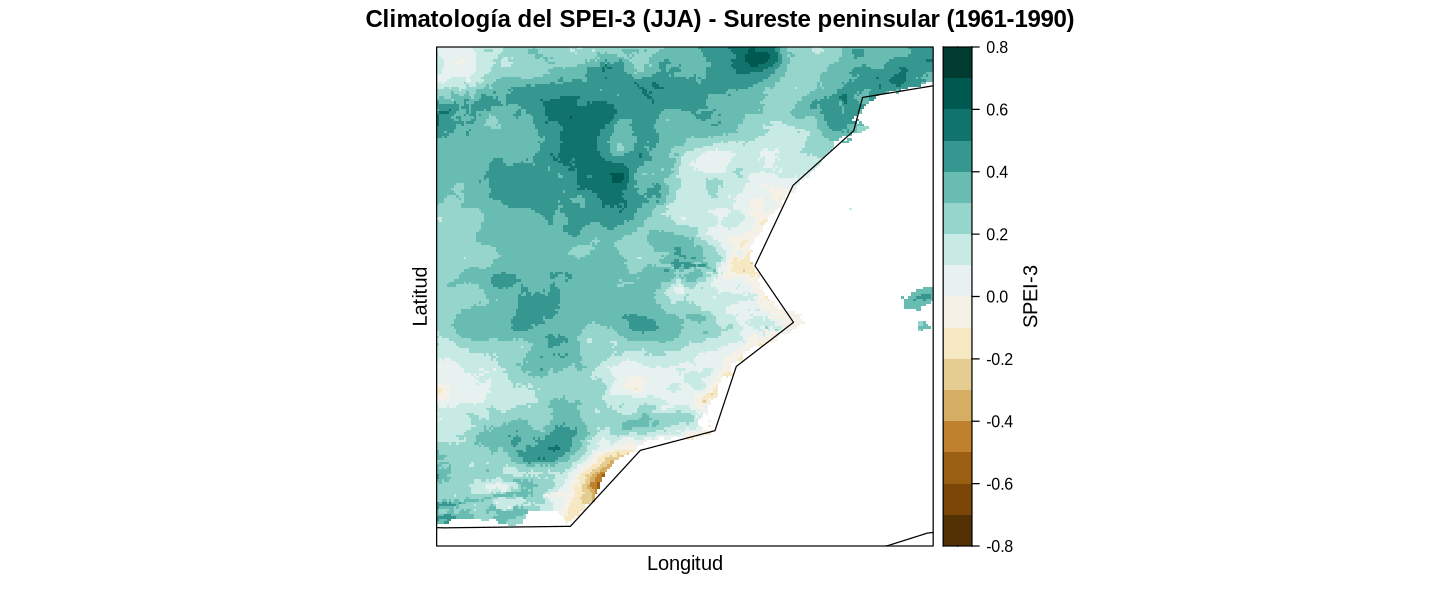

In [42]:
spatialPlot(climatology(spei3.p1),
            at             = seq(-0.8, 0.8, 0.1),
            main           = "Climatología del SPEI-3 (JJA) - Sureste peninsular (1961-1990)",
            backdrop.theme = "coastline",
            color.theme    = "BrBG",
            colorkey       = list(space = "right",
                                  title = list("SPEI-3", cex = 1)),
            xlab           = "Longitud",
            ylab           = "Latitud")

[2026-06-05 10:02:24.141894] - Computing climatology...

[2026-06-05 10:02:24.629534] - Done.



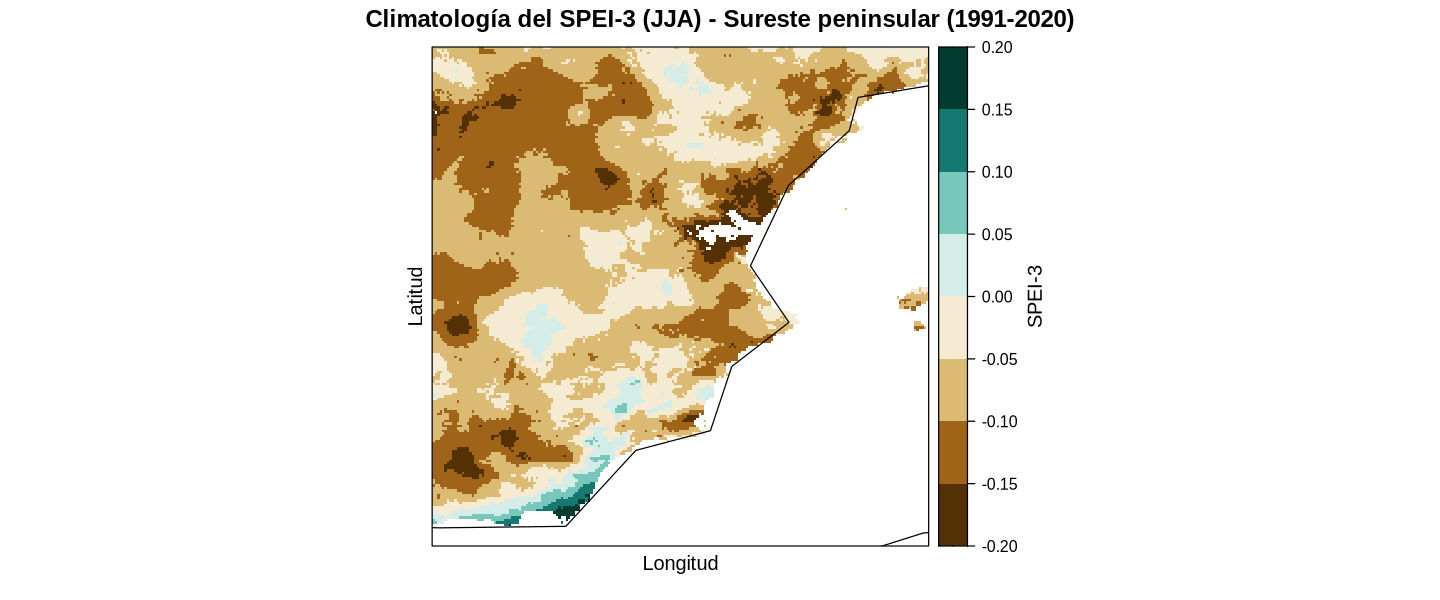

In [43]:
spatialPlot(climatology(spei3.p2),
            at             = seq(-0.2, 0.2, 0.05),
            main           = "Climatología del SPEI-3 (JJA) - Sureste peninsular (1991-2020)",
            backdrop.theme = "coastline",
            color.theme    = "BrBG",
            colorkey       = list(space = "right",
                                  title = list("SPEI-3", cex = 1)),
            xlab           = "Longitud",
            ylab           = "Latitud")

A continuación compararemos los resultados para los dos periodos consecutivos (1961-1990 y 1991-2020) para explorar posibles cambios en las condiciones de sequía. Para ello calculamos la diferencia de climatologías con `gridArithmetics`.

In [33]:
spei3.anom <- gridArithmetics(climatology(spei3.p2), climatology(spei3.p1), operator = "-")

[2026-06-05 09:56:21.43571] - Computing climatology...

[2026-06-05 09:56:21.905294] - Done.

[2026-06-05 09:56:21.930574] - Computing climatology...

[2026-06-05 09:56:22.369908] - Done.



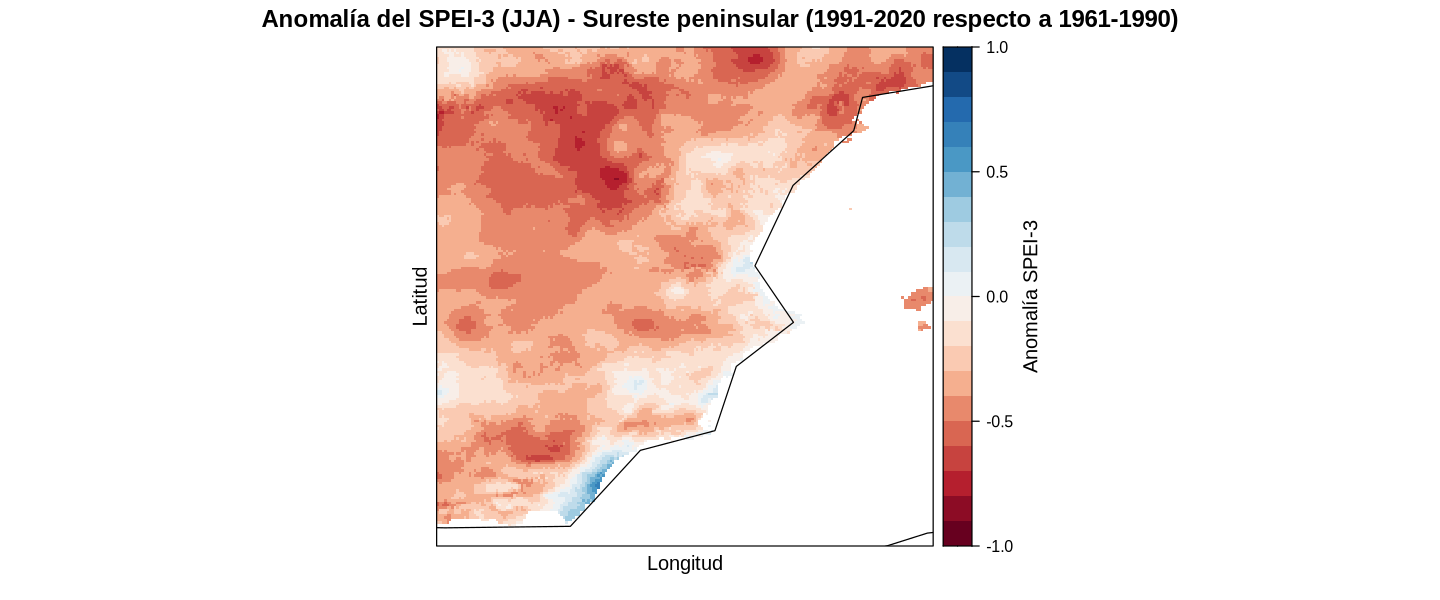

In [45]:
spatialPlot(spei3.anom,
            at             = seq(-1, 1, 0.1),
            set.max        = 1,
            set.min        = -1,
            main           = "Anomalía del SPEI-3 (JJA) - Sureste peninsular (1991-2020 respecto a 1961-1990)",
            backdrop.theme = "coastline",
            color.theme    = "RdBu",
            colorkey       = list(space = "right",
                                  title = list("Anomalía SPEI-3", cex = 1)),
            xlab           = "Longitud",
            ylab           = "Latitud")

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

La Plataforma Virtual de Cálculo ofrece un **notebook de primeros pasos** y una **colección de notebooks temáticos** (p. ej., intercomparación de conjuntos de datos observacionales o cálculo de índices) que puedes consultar para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.

In [46]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] magrittr_2.0.3      drought4R_0.3.1     visualizeR_1.6.4   
[4] transformeR_2.2.2   loadeR_1.8.1        climate4R.UDG_0.2.6
[7] loadeR.java_1.1.1   rJava_1.0-11        repr_1.1.7         

loaded via 